# Data Loading

In [2]:
import pandas as pd
import os

sample_file = '../data/raw/cdrs/sms-call-internet-mi-2013-11-01.txt'
columns = ['square_id', 'time_interval', 'country_code', 'sms_in', 'sms_out', 'call_in', 'call_out', 'internet']

# 1. The "Naive" Approach (Loading everything as float64/object)
df_naive = pd.read_csv(sample_file, sep='\t', header=None, names=columns)
naive_mem = df_naive.memory_usage(deep=True).sum() / (1024**2)

# 2. The "Optimized" Approach
dtypes = {'square_id': 'uint16', 'time_interval': 'uint64', 'internet': 'float32'}
df_optimized = pd.read_csv(sample_file, sep='\t', header=None, names=columns, 
                           usecols=['square_id', 'time_interval', 'internet'], dtype=dtypes)
opt_mem = df_optimized.memory_usage(deep=True).sum() / (1024**2)

print(f"Naive 1-Day Memory: {naive_mem:.2f} MB")
print(f"Optimized 1-Day Memory: {opt_mem:.2f} MB")
print(f"Reduction: {((naive_mem - opt_mem) / naive_mem) * 100:.1f}%")

# Extrapolate for the report
print(f"Projected Naive Memory for 62 days: {(naive_mem * 62) / 1024:.2f} GB")

Naive 1-Day Memory: 295.57 MB
Optimized 1-Day Memory: 64.66 MB
Reduction: 78.1%
Projected Naive Memory for 62 days: 17.90 GB


# Exploratory Data Analysis

Loading data...


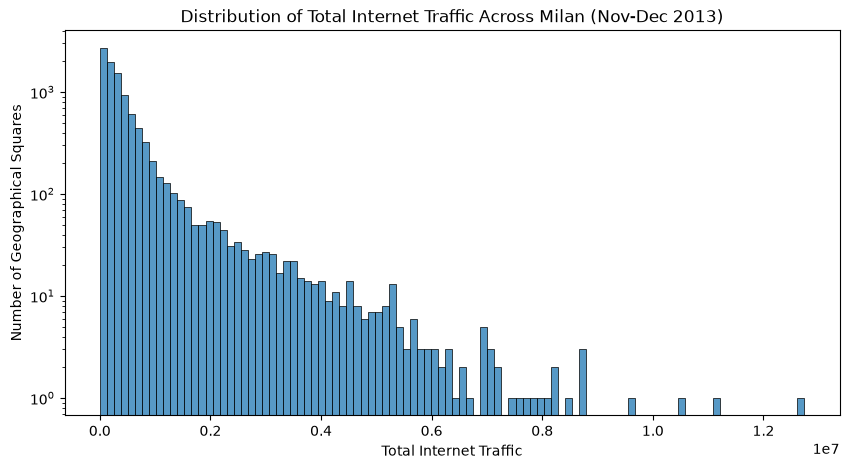

The Top 3 highest traffic squares are: [5161, 5059, 5259]


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load the optimized dataset
print("Loading data...")
df = pd.read_parquet('../data/processed/milan_internet_traffic.parquet')

# 2. Calculate total traffic per square over the entire 2 months
total_traffic = df.groupby('square_id')['internet'].sum().reset_index()
total_traffic = total_traffic.sort_values(by='internet', ascending=False)

# 3. Plot the distribution
plt.figure(figsize=(10, 5))
sns.histplot(total_traffic['internet'], bins=100, kde=False)
plt.title('Distribution of Total Internet Traffic Across Milan (Nov-Dec 2013)')
plt.xlabel('Total Internet Traffic')
plt.ylabel('Number of Geographical Squares')
plt.yscale('log') # Log scale helps visualize heavy-tailed distributions
plt.show()

# 4. Identify the Top 3
top_3_squares = total_traffic.head(3)['square_id'].tolist()
print(f"The Top 3 highest traffic squares are: {top_3_squares}")

The distribution of total internet traffic across Milan is heavily right-skewed. The vast majority of the 10,000 geographical areas exhibit very low aggregate traffic, which likely correspond to less densely populated areas such as suburbs, parks, or industrial outskirts. Conversely, a long tail extends to the right, indicating a small number of geographic areas handle an exceptionally high volume of internet traffic. The top three highest-traffic areas (Squares 5161, 5059, and 5259) represent these extreme outliers, likely corresponding to Milan's city center, major business districts, or transit hubs where dense crowds gather daily.

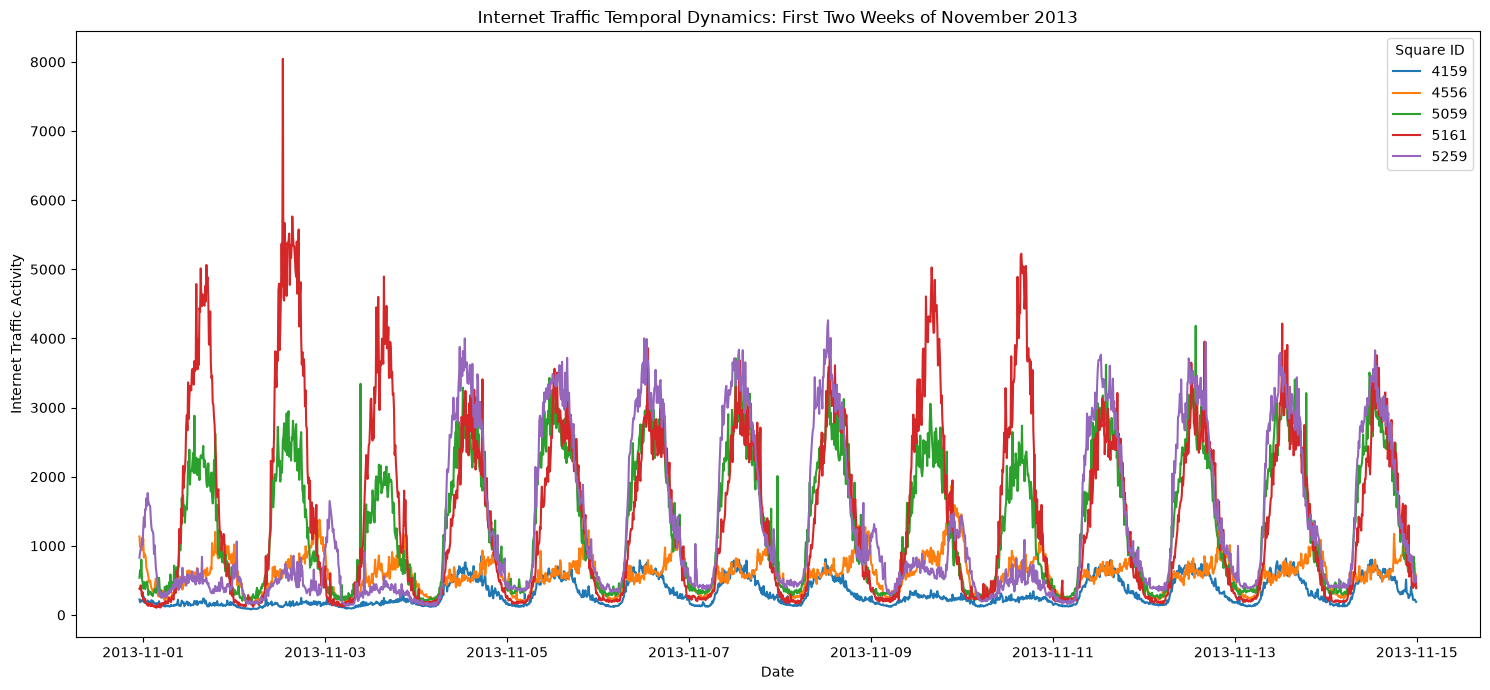

In [2]:
# 1. Define our target squares
target_squares = top_3_squares + [4159, 4556]

# 2. Filter the dataframe for just these squares and the first 14 days
# We use < '2013-11-15' to get exactly Nov 1 through Nov 14
two_weeks_df = df[(df['square_id'].isin(target_squares)) & 
                  (df['datetime'] < '2013-11-15')].copy()

# 3. Plot the time series
plt.figure(figsize=(15, 7))
sns.lineplot(data=two_weeks_df, x='datetime', y='internet', hue='square_id', palette='tab10')

plt.title('Internet Traffic Temporal Dynamics: First Two Weeks of November 2013')
plt.xlabel('Date')
plt.ylabel('Internet Traffic Activity')
plt.legend(title='Square ID')
plt.tight_layout()
plt.show()

The internet traffic across all selected areas exhibits a clear daily cyclical pattern, dropping to near-zero during the early morning hours and experiencing sharp peaks around midday and early afternoon. Despite this shared rhythm, the geographical areas display distinct functional behaviors. Squares 5161 and 5059 experience massive traffic spikes during typical working hours on weekdays, suggesting they are commercial hubs or city centers. Conversely, square 4556 features a much flatter temporal profile with peaks occurring later in the evening. This delayed phase shift indicates area 4556 is likely a residential zone where internet usage rises after standard working hours rather than during the midday rush.

The high-volume area 5259 demonstrates a stark contrast between weekdays and weekends, with traffic volume dropping significantly during the weekend of November 9th and 10th. Furthermore, the traffic is unusually depressed on Friday, November 1st. Because November 1st is All Saints' Day, a major public holiday in Italy, this area effectively experienced a three-day lull in activity. This holiday anomaly further confirms its status as an office or academic district rather than a residential one. These distinct temporal dynamics prove that the final forecasting models must account for daily seasonality, day-of-the-week effects, and holiday anomalies to make accurate predictions.

/tmp/ipykernel_3021107/1696097503.py:11: FutureWarning: `extrapolate_trend='freq'` is deprecated and will be removed in 0.16, use `extrapolate_trend='period'` instead.
  decomposition = sm.tsa.seasonal_decompose(traffic_series.dropna(), period=144, extrapolate_trend='freq')


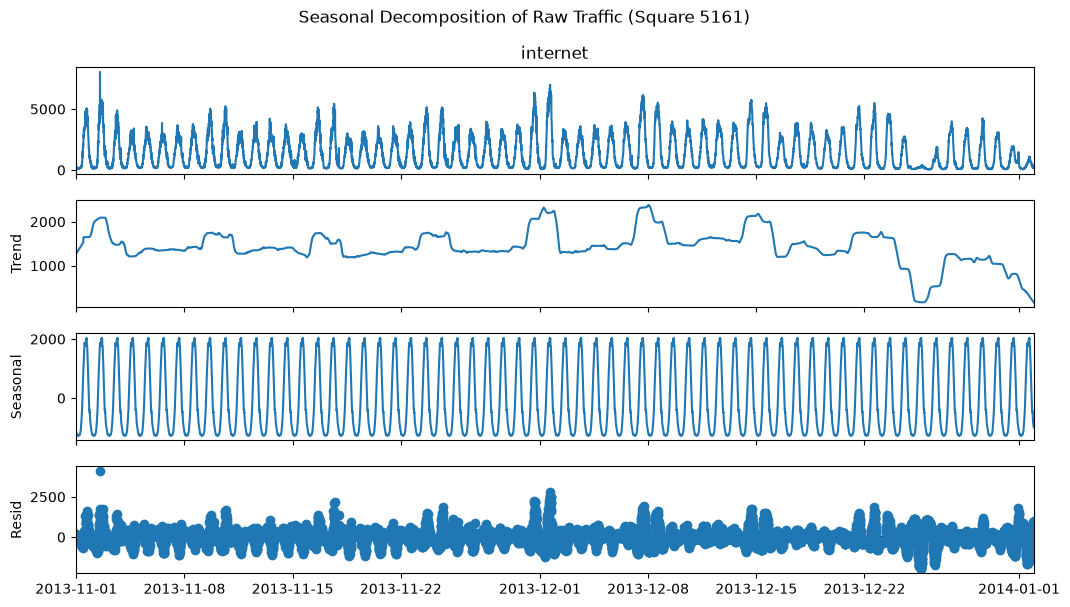

ADF Statistic: -19.0319
p-value: 0.0000e+00


/tmp/ipykernel_3021107/1696097503.py:18: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  adf_result = adfuller(traffic_series.dropna())


In [7]:
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller

# Isolate the data for the highest traffic square
df_top = df[df['square_id'] == 5161].copy()
df_top = df_top.set_index('datetime')
traffic_series = df_top['internet']

# --- Seasonal Decomposition & Stationarity ---
decomposition = sm.tsa.seasonal_decompose(traffic_series.dropna(), period=144, extrapolate_trend='freq')
fig = decomposition.plot()
fig.set_size_inches(12, 6)
plt.suptitle('Seasonal Decomposition of Raw Traffic (Square 5161)', y=1.02)
plt.show()

# Augmented Dickey-Fuller Test
adf_result = adfuller(traffic_series.dropna())
print(f"ADF Statistic: {adf_result[0]:.4f}")
print(f"p-value: {adf_result[1]:.4e}")

The seasonal decomposition isolates a strong, deterministic daily repeating pattern within the internet traffic. Despite these massive intraday fluctuations, the Augmented Dickey-Fuller (ADF) test yields a p-value of 0.0000, which firmly rejects the null hypothesis of a unit root. This mathematically proves the time series is stochastically stationary; the data maintains a constant baseline mean over the two-month period and does not wander toward infinity.

Because the series is stationary, standard first-order trend differencing (e.g., an ARIMA $d$ parameter of 0) is unnecessary. However, the pronounced daily seasonality dictates that a standard sequential baseline will be insufficient. This observation suggests the need to explore architectures capable of explicitly managing periodic cycles—whether through statistical models incorporating seasonal or exogenous features, or deep learning frameworks equipped to handle long sequence dependencies.

To determine potential Autoregressive (AR) and Moving Average (MA) dynamics, we must evaluate the Autocorrelation (ACF) and Partial Autocorrelation (PACF) functions. If evaluated on the raw time series, the massive 24-hour seasonal wave would completely dominate the correlograms, masking the underlying short-term lag correlations. Therefore, the next step is to apply a seasonal difference (lag 144) to strip away this deterministic cycle, isolating the residual relationships needed to inform candidate model architectures.

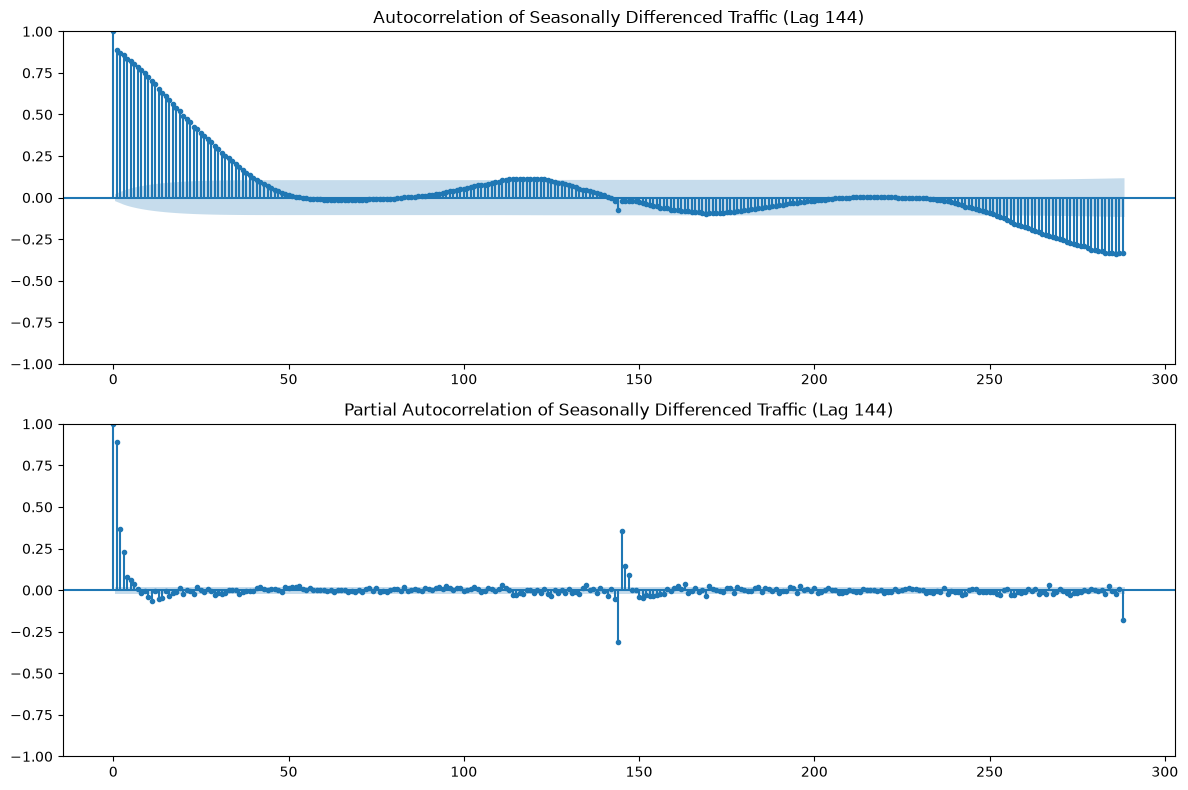

In [8]:
# --- Seasonally Differenced ACF & PACF ---
# Apply seasonal differencing (144 steps = 24 hours)
differenced_series = traffic_series.diff(144).dropna()

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))

# Plot the new differenced ACF and PACF
sm.graphics.tsa.plot_acf(differenced_series, lags=288, ax=ax1, markersize=3)
ax1.set_title('Autocorrelation of Seasonally Differenced Traffic (Lag 144)')

sm.graphics.tsa.plot_pacf(differenced_series, lags=288, ax=ax2, markersize=3, method='ywm')
ax2.set_title('Partial Autocorrelation of Seasonally Differenced Traffic (Lag 144)')

plt.tight_layout()
plt.show()

The application of a seasonal difference (lag 144) successfully removes the dominant 24-hour sinusoidal wave, revealing the underlying autoregressive properties of the internet traffic. The differenced Autocorrelation Function (ACF) exhibits a gradual decay over the first 35 lags, indicating a strong, lingering short-term dependence between consecutive time steps. More importantly, the Partial Autocorrelation Function (PACF) isolates the direct lag effects, displaying prominent initial spikes at lags 1, 2, and 3 before dropping sharply toward zero. Furthermore, the PACF shows a distinct, statistically significant spike exactly at lag 144, with minor subsequent variations around lags 145 to 148.

These findings provide clear directional guidance for model selection. The sharp cut-off in the initial PACF lags suggests that the immediate short-term memory of the system is relatively brief; the traffic at any given moment is heavily reliant on only the preceding 30 to 40 minutes. However, the isolated spike at lag 144 confirms that a strong deterministic seasonal dependency persists. Standard models lacking a 24-hour memory mechanism will therefore fail to capture the full temporal dynamics. To achieve accurate one-step-ahead forecasting, candidate models will likely need to incorporate extensive lookback windows (at least 144 lags) for neural networks, utilize Fourier-based exogenous terms in statistical frameworks, or integrate engineered temporal features (such as hour-of-day) to bridge the gap between the short-term AR dependencies and the 24-hour seasonal baseline.